In [1]:
import h5py
import numpy as np
from astropy import units
from IPython.display import clear_output
import matplotlib.pyplot as plt
import matplotlib.colors as colors


In [2]:
data = h5py.File("TNG100-1_subhalosCat.hdf5", 'r')

In [3]:
#get data functions with correct units
def gethubble(data):
    hubble_param = data["Header"].attrs["HubbleParam"]
    return hubble_param

def getbox_size(data):
    hubble_param = gethubble(data)
    raw_box_size = data["Header"].attrs["BoxSize"]
    box_size = (raw_box_size / hubble_param) * units.kpc
    return box_size

#position of subhalo compared to periodic box. Position is of particle with minimum gravitational potential energy.
def getsubhalo_pos(data):
    hubble_param = gethubble(data)
    raw_subhalo_pos = data["Subhalo"]["SubhaloPos"]                  #is in ckpc/h
    subhalo_pos = (raw_subhalo_pos / hubble_param) * units.kpc
    return subhalo_pos

#cm of each subhalo, determined with all types of particles.
def getsubhalo_cm(data):
    hubble_param = gethubble(data)
    raw_subhalo_cm = data["Subhalo"]["SubhaloCM"]                    #is in ckpc/h
    subhalo_cm = (raw_subhalo_cm / hubble_param) * units.kpc
    return subhalo_cm

#total mass of all particles of subhalo. subhalo's of a subhalo not included in mass.
def getsubhalo_mass(data):
    hubble_param = gethubble(data)
    raw_subhalo_mass = np.array(data["Subhalo"]["SubhaloMass"])              #is in 10**10 solmass/h
    subhalo_mass = (raw_subhalo_mass*1e10/hubble_param) * units.Msun
    return subhalo_mass

#total mass of subhalo by particle type. 
def getsubhalo_massbytype(data):
    hubble_param = gethubble(data)
    raw_subhalo_massbytype = np.array(data["Subhalo"]["SubhaloMassType"])      #is in 10**10 solmass/h
    subhalo_massbytype = (raw_subhalo_massbytype*1e10/hubble_param) * units.Msun
    #Nx6, [Gas, DM, UNUSED, Tracers, Stars/wind particles, Black holes]
    return subhalo_massbytype

In [70]:
#boolean numpy array stating if a subhalo at that index contains a galaxy. 
def getgalaxy_mask(data):
    mass_type = getsubhalo_massbytype(data)
    stellar_mass = mass_type[:,4]
    mask1 = data["Subhalo"]["SubhaloFlag"]
    mask2 = (stellar_mass > 7*10**7 * units.Msun)
    mass_t = getsubhalo_mass(data)
    mask3 = (stellar_mass != mass_t)
    mask4 = (mass_t > 3.75*10**8 * units.Msun)
    mask5 = (mass_type[:, 1] > 0)
    return mask1 * mask2 * mask3 * mask4 * mask5

def getgalaxy_stellar_mass(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_mass = getsubhalo_massbytype(data)
    total_subhalo_mass = getsubhalo_mass(data)
    
    total_gal_mass = total_subhalo_mass[galaxy_mask]
    
    galaxy_mass = subhalo_mass[galaxy_mask, :]
    galaxy_stellar_mass = galaxy_mass[:,4]
    
    return total_gal_mass, galaxy_stellar_mass

def getgalaxy_DM_mass(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_mass = getsubhalo_massbytype(data)
    total_subhalo_mass = getsubhalo_mass(data)
    
    total_gal_mass = total_subhalo_mass[galaxy_mask]
    
    galaxy_mass = subhalo_mass[galaxy_mask, :]
    galaxy_DM_mass = galaxy_mass[:,1]
    
    return total_gal_mass, galaxy_DM_mass

In [71]:
galaxy_mass, galaxy_stellar_mass = getgalaxy_stellar_mass(data)

In [72]:
print(galaxy_stellar_mass)

[6.75072753e+11 3.19900889e+11 9.81360664e+10 ... 8.15045385e+08
 3.37326224e+08 7.94137349e+07] solMass


In [73]:
print(galaxy_mass)

[5.24105467e+13 1.37840470e+13 2.03133040e+12 ... 5.09160342e+09
 3.06895003e+09 4.79631608e+09] solMass


In [74]:
print(len(galaxy_mass))

55306


In [75]:
galaxy_mass, galaxy_DM_mass = getgalaxy_DM_mass(data)

In [76]:
print(len(galaxy_mass))


55306


In [52]:
# Define grid
steps = 200
x_ = np.linspace(8  + np.log10(3.75), 15, steps)
y_ = np.linspace(7 + np.log10(7), 13, steps)
# Create empty array for potentials
counts_xy = np.zeros((len(y_), len(x_)))


dx = (x_.max() - x_.min()) / (steps - 1)
dy = (y_.max() - y_.min()) / (steps - 1)

m = np.log10(galaxy_mass / units.Msun)
s = np.log10(galaxy_stellar_mass / units.Msun)

s_means = np.zeros(len(x_))
s_medians = np.zeros(len(x_))

for i, x in enumerate(x_):
    mass_mask = (m >= x) & (m < x + dx)
    for j, y in enumerate(y_):
        stel = s[mass_mask]
        s_means[i] = np.mean(stel)
        s_medians[i] = np.median(stel)
        counts_xy[j, i] = ((stel >= y) & (stel < y + dy)).sum()

C:\Users\brent\anaconda3\envs\TANA2025\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\brent\anaconda3\envs\TANA2025\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


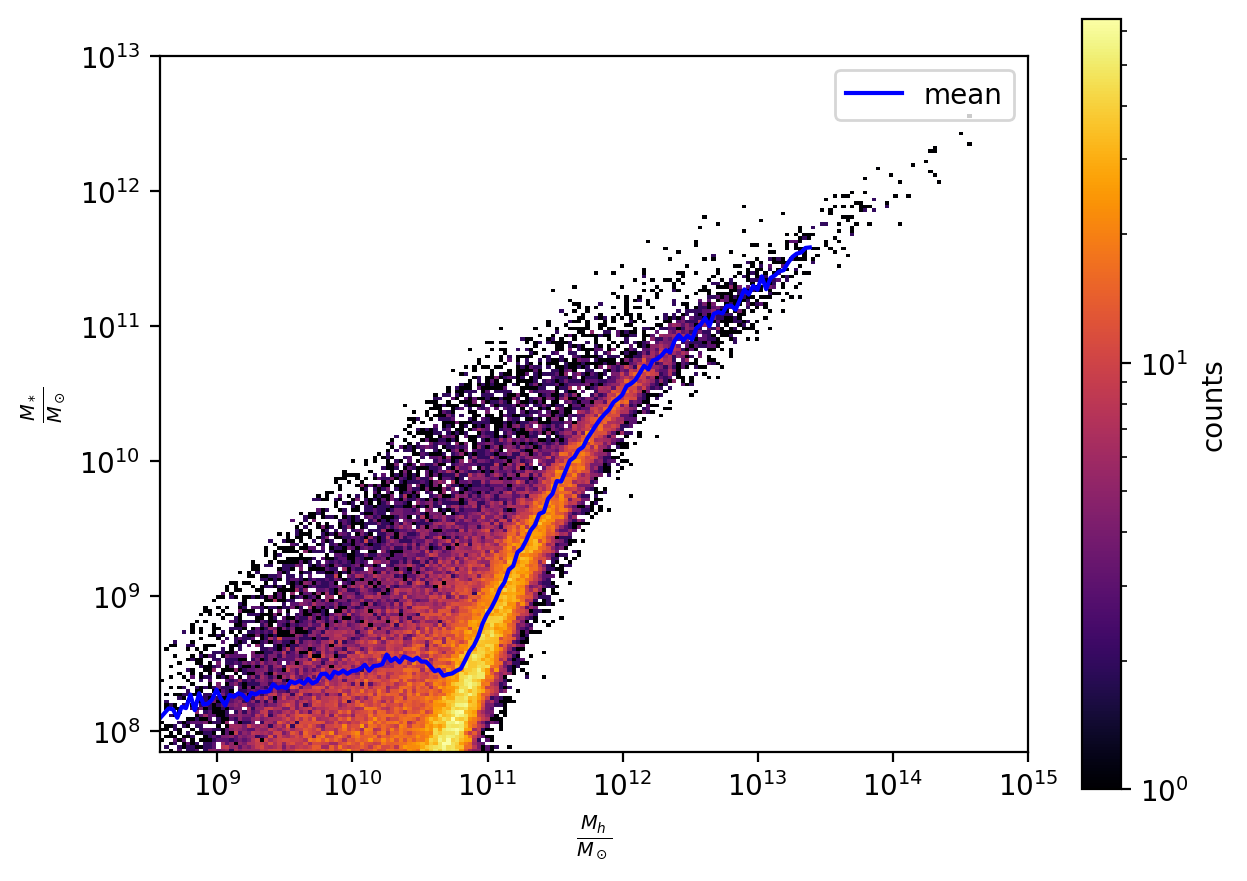

In [53]:
# Plot colormap
plt.figure(figsize=(7,5), dpi=200)
plt.imshow(counts_xy, origin='lower', extent=[8 + np.log10(3.75), 15, 7 + np.log10(7), 13], cmap='inferno', norm=colors.LogNorm())
plt.plot(x_[:150], s_means[:150], color='b', label='mean')
#plt.plot(x_, s_medians)
#plt.plot(x_, x_)
plt.colorbar(label=r'counts')
plt.xlabel(r'$\frac{M_h}{M_\odot}$')
plt.ylabel(r'$\frac{M_*}{M_\odot}$')
plt.legend()
plt.xticks([9, 10, 11, 12, 13, 14, 15], [r'$10^9$', r'$10^{10}$', r'$10^{11}$', r'$10^{12}$', r'$10^{13}$', r'$10^{14}$', r'$10^{15}$'])
plt.yticks([8, 9, 10, 11, 12, 13], [r'$10^8$', r'$10^9$', r'$10^{10}$', r'$10^{11}$', r'$10^{12}$', r'$10^{13}$'])
plt.savefig('SHMR_xy')
plt.show()


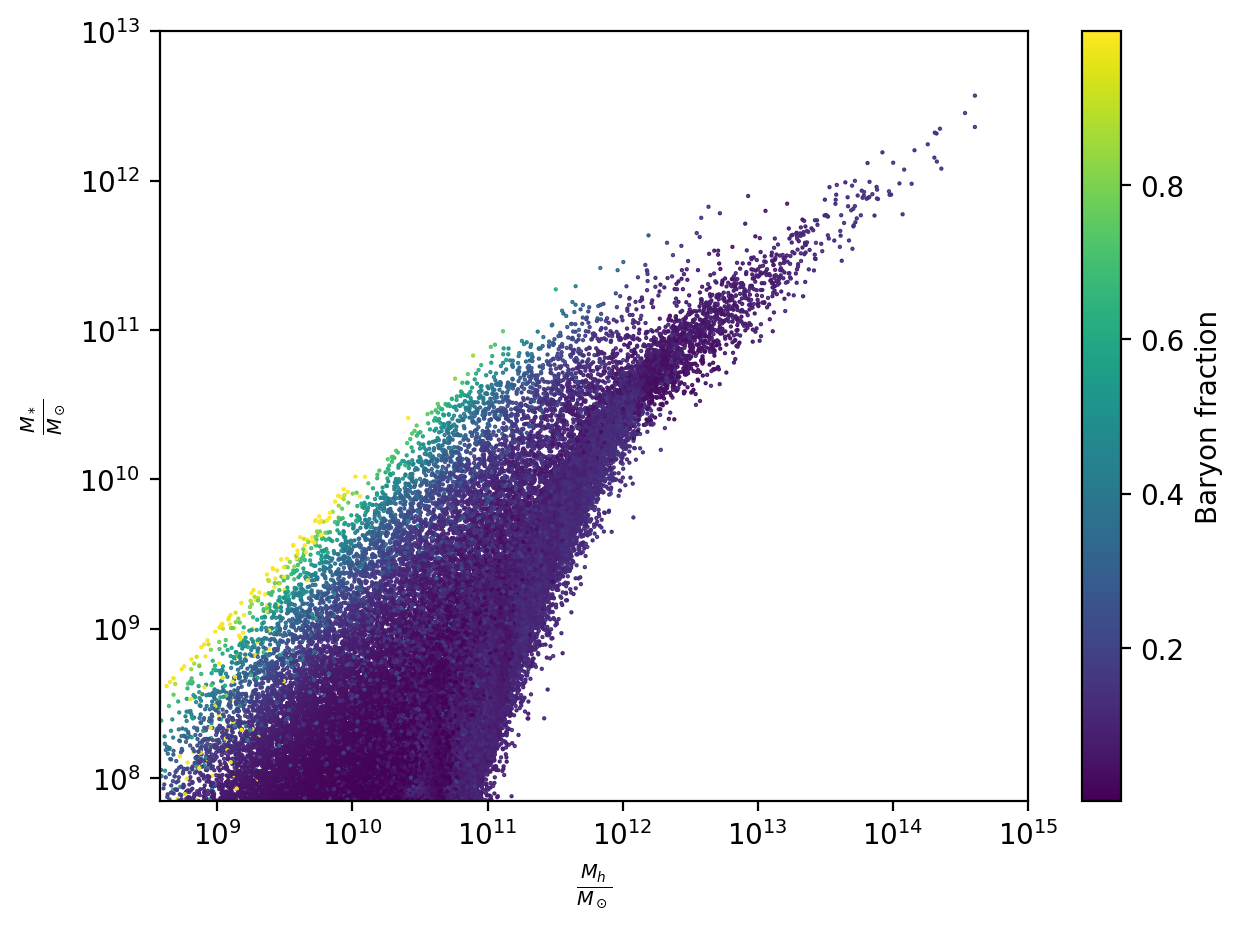

In [55]:

# Create empty array for potentials
m = np.log10(galaxy_mass / units.Msun)
s = np.log10(galaxy_stellar_mass / units.Msun)
b = (galaxy_mass - galaxy_DM_mass)/galaxy_mass

fig, ax = plt.subplots(figsize=(7,5), dpi=200)
pl = ax.scatter(m, s,  s = 0.3, c=b, cmap='viridis')
plt.colorbar(pl, label='Baryon fraction')
#ax.set_xscale('log', base=10)
#ax.set_yscale('log', base=10)
plt.xlabel(r'$\frac{M_h}{M_\odot}$')
plt.ylabel(r'$\frac{M_*}{M_\odot}$')
plt.xlim(8  + np.log10(3.75), 15)
plt.ylim(7 + np.log10(7), 13)
plt.xticks([9, 10, 11, 12, 13, 14, 15], [r'$10^9$', r'$10^{10}$', r'$10^{11}$', r'$10^{12}$', r'$10^{13}$', r'$10^{14}$', r'$10^{15}$'])
plt.yticks([8, 9, 10, 11, 12, 13], [r'$10^8$', r'$10^9$', r'$10^{10}$', r'$10^{11}$', r'$10^{12}$', r'$10^{13}$'])
plt.savefig('SHMR_baryon')
plt.show()

In [86]:
# Define grid
steps = 200
x_ = np.linspace(8  + np.log10(3.75), 15, steps)
y_ = np.linspace(0, 1/0.158, steps)
# Create empty array for potentials
counts_xy = np.zeros((len(y_), len(x_)))


dx = (x_.max() - x_.min()) / (steps - 1)
dy = (y_.max() - y_.min()) / (steps - 1)

m = np.log10(galaxy_mass / units.Msun)
s = (galaxy_mass - galaxy_DM_mass)/galaxy_mass / 0.158

s_means = np.zeros(len(x_))
s_medians = np.zeros(len(x_))

for i, x in enumerate(x_):
    mass_mask = (m >= x) & (m < x + dx)
    for j, y in enumerate(y_):
        stel = s[mass_mask]
        s_means[i] = np.mean(stel)
        s_medians[i] = np.median(stel)
        counts_xy[j, i] = ((stel >= y) & (stel < y + dy)).sum()

C:\Users\brent\anaconda3\envs\TANA2025\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\brent\anaconda3\envs\TANA2025\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


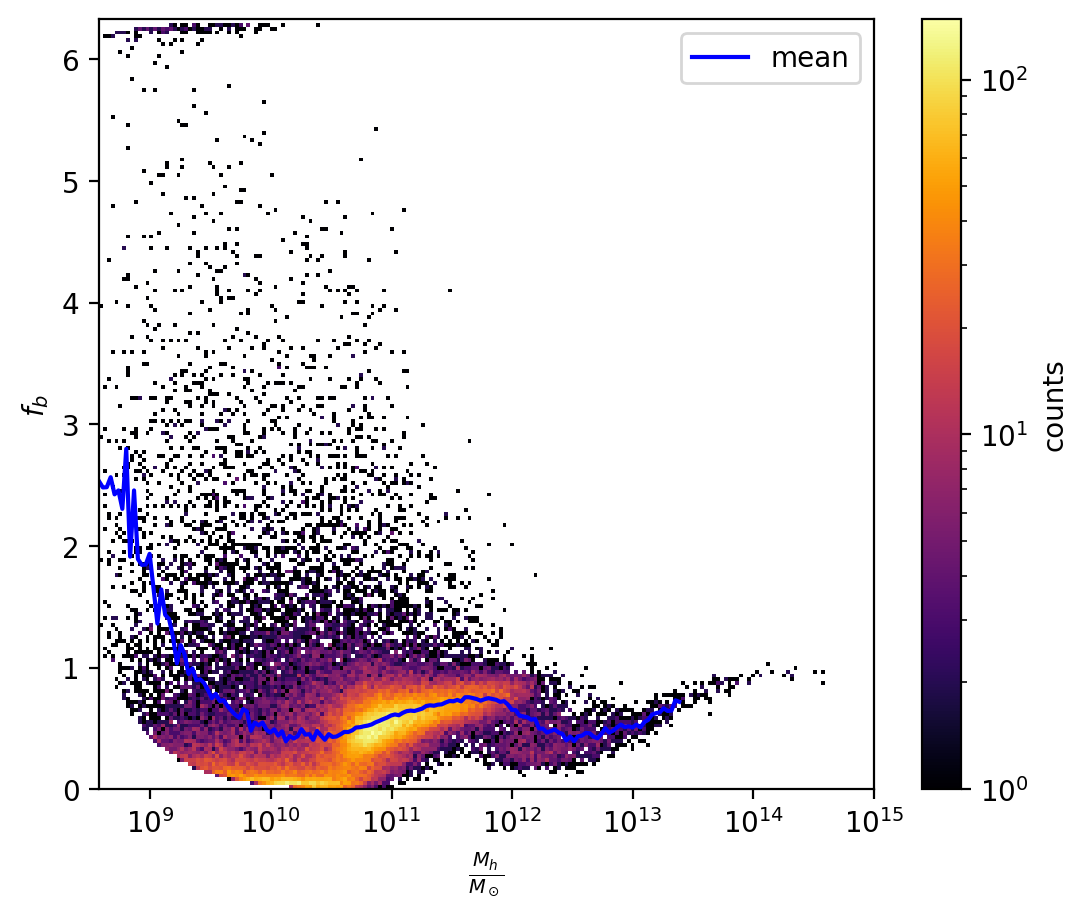

In [87]:
# Plot colormap
plt.figure(figsize=(5/0.80, 5), dpi=200)
plt.imshow(counts_xy, origin='lower', cmap='inferno',extent=[8 + np.log10(3.75), 15, 0, 1/0.158], norm=colors.LogNorm(), aspect='auto')
plt.plot(x_[:150], s_means[:150], color='b', label='mean')
#plt.plot(x_, s_medians)
#plt.plot(x_, x_)
plt.colorbar(label=r'counts')
plt.xlabel(r'$\frac{M_h}{M_\odot}$')
plt.ylabel(r'$f_b$')
plt.legend()
plt.xticks([9, 10, 11, 12, 13, 14, 15], [r'$10^9$', r'$10^{10}$', r'$10^{11}$', r'$10^{12}$', r'$10^{13}$', r'$10^{14}$', r'$10^{15}$'])
#plt.yticks([8, 9, 10, 11, 12, 13], [r'$10^8$', r'$10^9$', r'$10^{10}$', r'$10^{11}$', r'$10^{12}$', r'$10^{13}$'])
plt.savefig('f_b')
plt.show()


In [15]:
galaxy_mass, galaxy_DM_mass = getgalaxy_DM_mass(data)

In [24]:
# Define grid
steps = 200
x_ = np.linspace(8 + np.log10(3.75), 15, steps)
y_ = np.linspace(0, 1, steps)
# Create empty array
counts_xy = np.zeros((len(y_), len(x_)))


dx = (x_.max() - x_.min()) / (steps - 1)
dy = (y_.max() - y_.min()) / (steps - 1)

m = np.log10(galaxy_mass / units.Msun)
s = np.log10((galaxy_mass - galaxy_DM_mass) / galaxy_mass)

for i, x in enumerate(x_):
    mass_mask = (m >= x) & (m < x + dx)
    for j, y in enumerate(y_):
        stel = s[mass_mask]
        counts_xy[j, i] = ((stel >= y) & (stel < y + dy)).sum()

[[6. 4. 5. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [39]:
# Define grid
steps = 200
x_ = np.linspace(8  + np.log10(3.75), 15, steps)
y_ = np.linspace(-4, 0, steps)
# Create empty array for potentials
counts_xy = np.zeros((len(y_), len(x_)))


dx = (x_.max() - x_.min()) / (steps - 1)
dy = (y_.max() - y_.min()) / (steps - 1)

m = np.log10(galaxy_mass / units.Msun)
s = np.log10(galaxy_stellar_mass / galaxy_mass)

s_means = np.zeros(len(x_))
s_medians = np.zeros(len(x_))

for i, x in enumerate(x_):
    mass_mask = (m >= x) & (m < x + dx)
    for j, y in enumerate(y_):
        stel = s[mass_mask]
        s_means[i] = np.mean(stel)
        s_medians[i] = np.median(stel)
        counts_xy[j, i] = ((stel >= y) & (stel < y + dy)).sum()

C:\Users\brent\anaconda3\envs\TANA2025\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\brent\anaconda3\envs\TANA2025\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


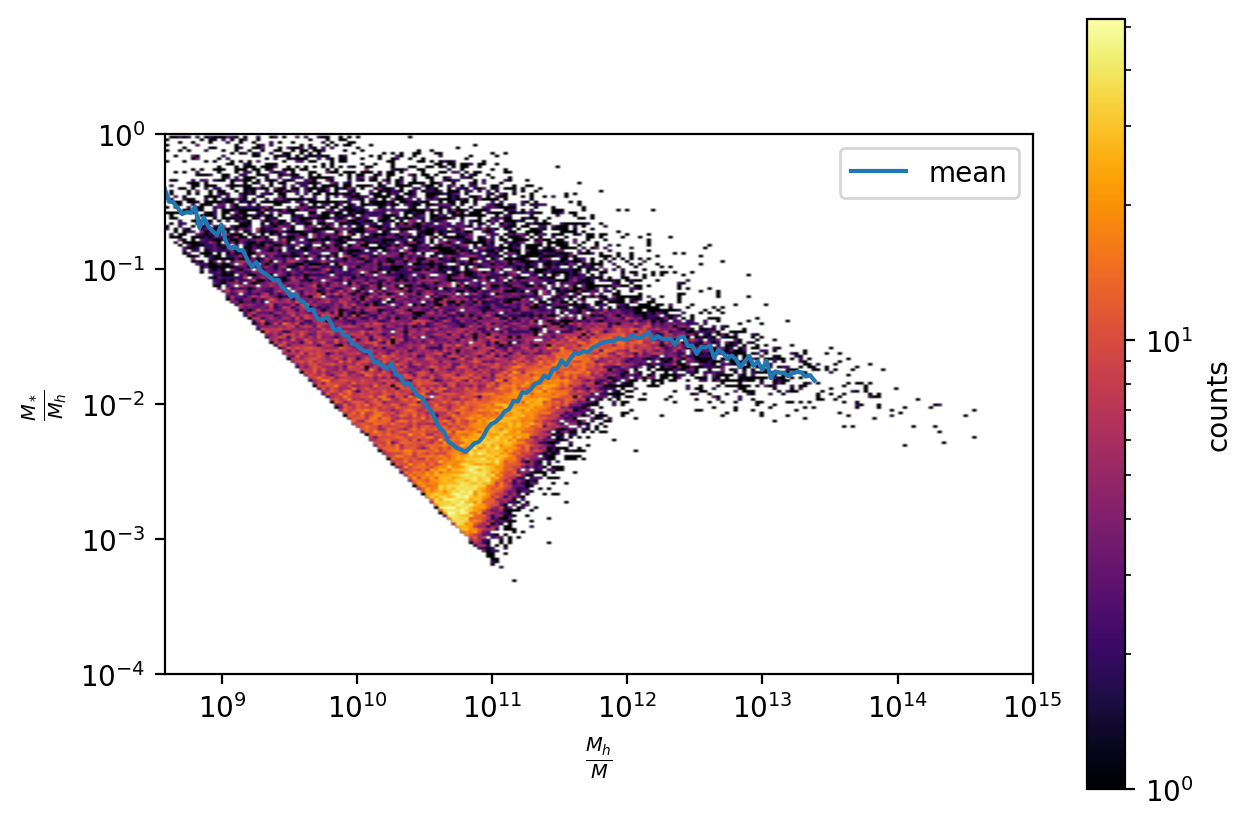

In [41]:
# Plot colormap
plt.figure(figsize=(7,5), dpi=200)
plt.imshow(counts_xy, origin='lower', extent=[8 + np.log10(3.75), 15, -4, 0], cmap='inferno', norm=colors.LogNorm())
plt.plot(x_[:150], s_means[:150], label='mean')
#plt.plot(x_, s_medians)
#plt.plot(x_, x_)
plt.colorbar(label=r'counts')
plt.xlabel(r'$\frac{M_h}{M}$')
plt.ylabel(r'$\frac{M_*}{M_h}$')
plt.legend()
plt.xticks([9, 10, 11, 12, 13, 14, 15], [r'$10^9$', r'$10^{10}$', r'$10^{11}$', r'$10^{12}$', r'$10^{13}$', r'$10^{14}$', r'$10^{15}$'])
plt.yticks([-4, -3, -2, -1, 0], [r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$'])
plt.savefig('SHMR_mh')
plt.show()
